In [1]:
from run_simulation import run_simulation, print_statistics
import simpy

# Run the simulation
num_permits = 6410
print("Running simulation with " + str(num_permits) + " permits...")
sim = run_simulation(
    num_permits=num_permits,
    random_seed=42,
    inter_arrival_time=0,
    sequential = "standard",
    pct_pre_approved=0,
    pct_custom=1,
    pct_self_cert=0,
    pct_like_for_like=0
)

# Get and display statistics
stats = sim.get_statistics()
print_statistics(stats)

Running simulation with 6410 permits...

SIMULATION STATISTICS

Total Completed Permits: 6410
Total In Progress: 0

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   :    0 ( 0.00%)
  CUSTOM_NON_LIKE               : 6410 (100.00%)
  PRE_APPROVED_LIKE             :    0 ( 0.00%)
  PRE_APPROVED_NON_LIKE         :    0 ( 0.00%)
  SELF_CERT_LIKE                :    0 ( 0.00%)
  SELF_CERT_NON_LIKE            :    0 ( 0.00%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     482.76 days
  Median:   481.66 days
  Std Dev:  200.13 days
  Min:       95.03 days
  Max:     1331.80 days

--------------------------------------------------------------------------------
PROCESSING T

In [2]:
# Optional: Access individual permit data
print(f"\nFirst 5 completed permits:")
for permit in sim.completed_permits[:5]:
    total_time = permit.ready_for_construction - permit.created_at if permit.ready_for_construction else None
    print(f"  Permit {permit.permit_id} ({permit.segment.name}): "
          f"{total_time:.2f} days total, "
          f"{permit.public_works_rechecks} re-checks")



First 5 completed permits:
  Permit 284 (CUSTOM_NON_LIKE): 95.03 days total, 1 re-checks
  Permit 499 (CUSTOM_NON_LIKE): 96.13 days total, 1 re-checks
  Permit 440 (CUSTOM_NON_LIKE): 99.71 days total, 1 re-checks
  Permit 662 (CUSTOM_NON_LIKE): 102.26 days total, 1 re-checks
  Permit 634 (CUSTOM_NON_LIKE): 108.29 days total, 0 re-checks


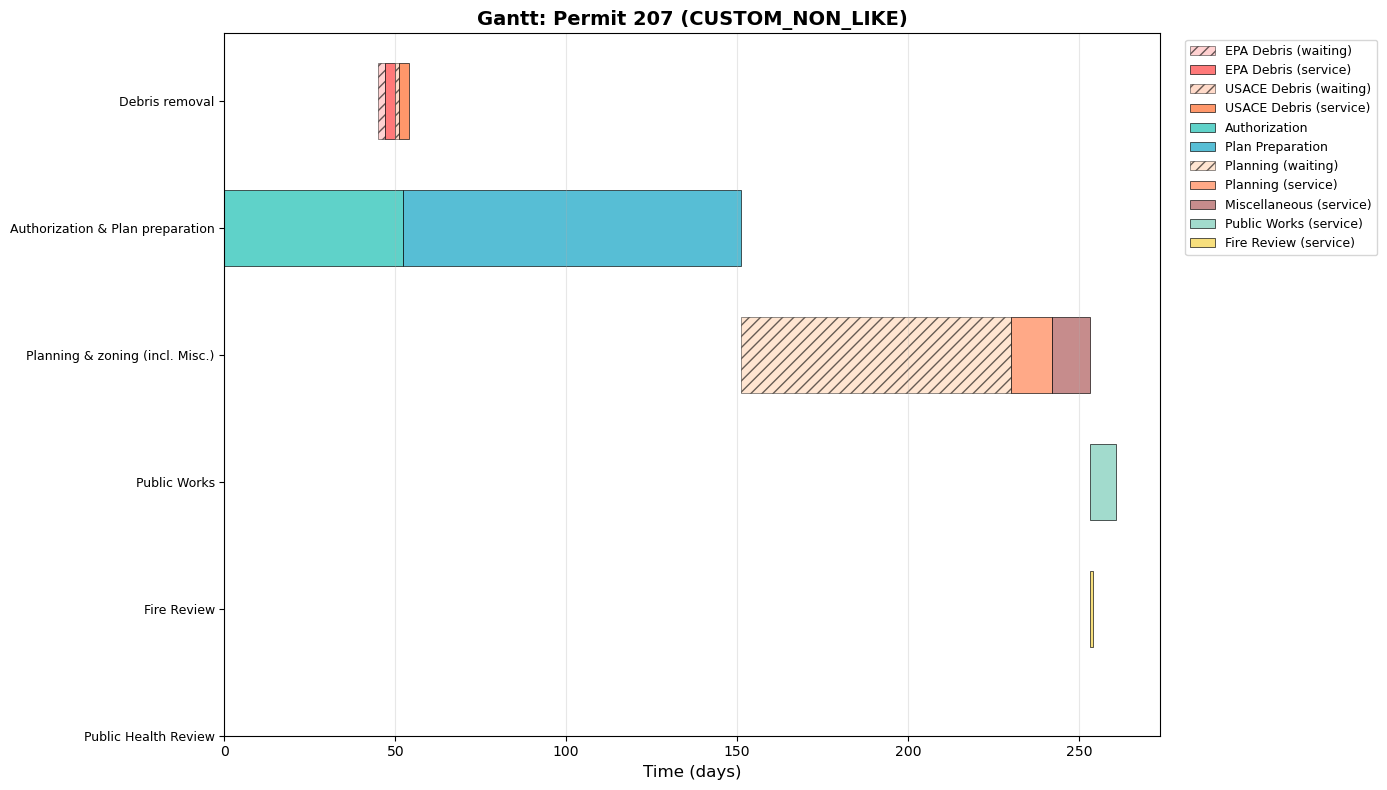

In [3]:
# Gantt chart for one random permit in segment 4 (CUSTOM_NON_LIKE)
# Parallel activities (e.g. Public Works, Fire Review, Public Health) appear on separate rows
from visualize_permits import plot_gantt_one_random_permit_segment
import matplotlib.pyplot as plt

fig, ax = plot_gantt_one_random_permit_segment(
    sim.completed_permits,
    segment_value=4,
    random_seed=65,
    figsize=(14, 8),
)
if fig:
    plt.show()

Creating visualizations for 6410 permits...
  Creating stacked bar chart...
  Creating average time by stage chart...
  Creating time by segment chart...
  Creating time by segment chart (Like-for-like only)...
  Creating time by segment chart (Non-like-for-like only)...
  Creating total time by segment chart (box plot)...
  Creating waiting vs service by step chart...


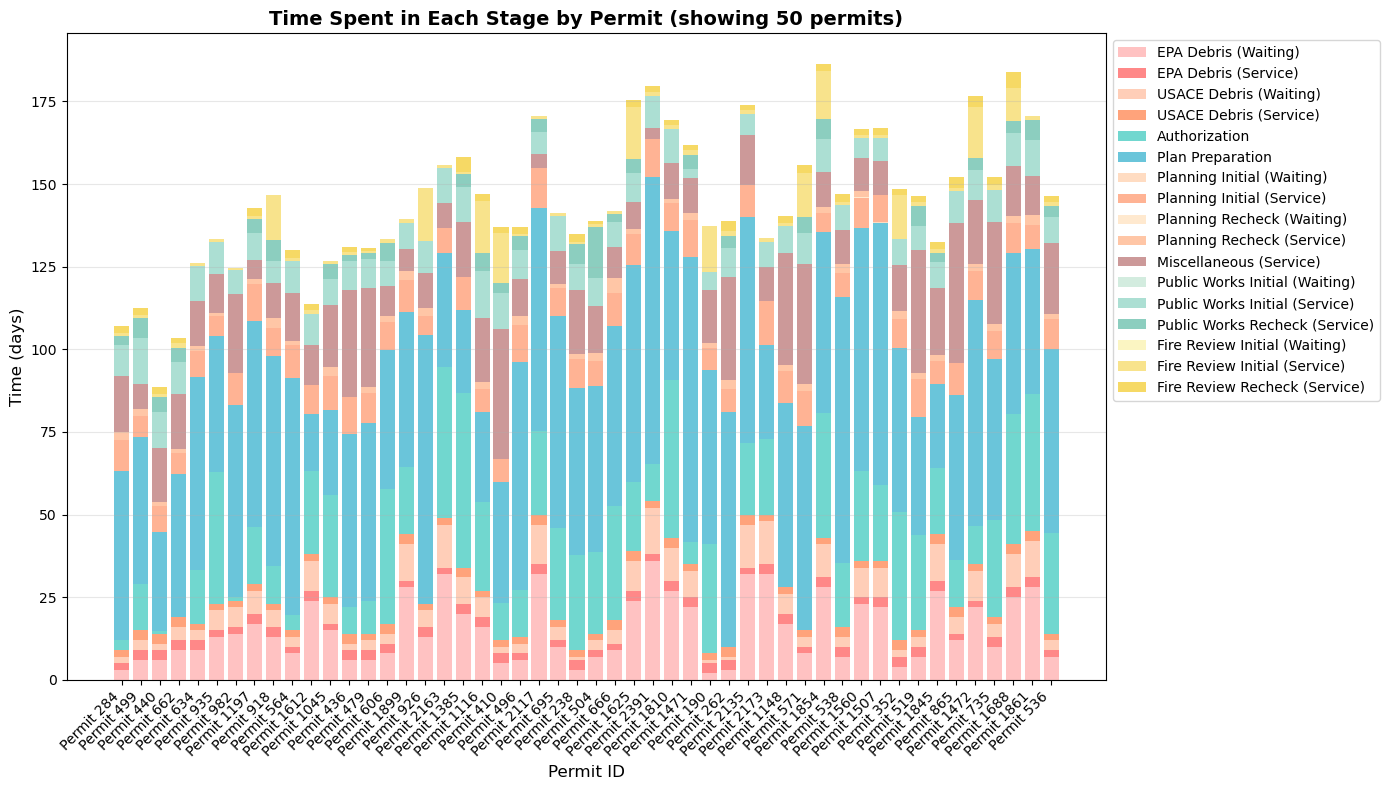

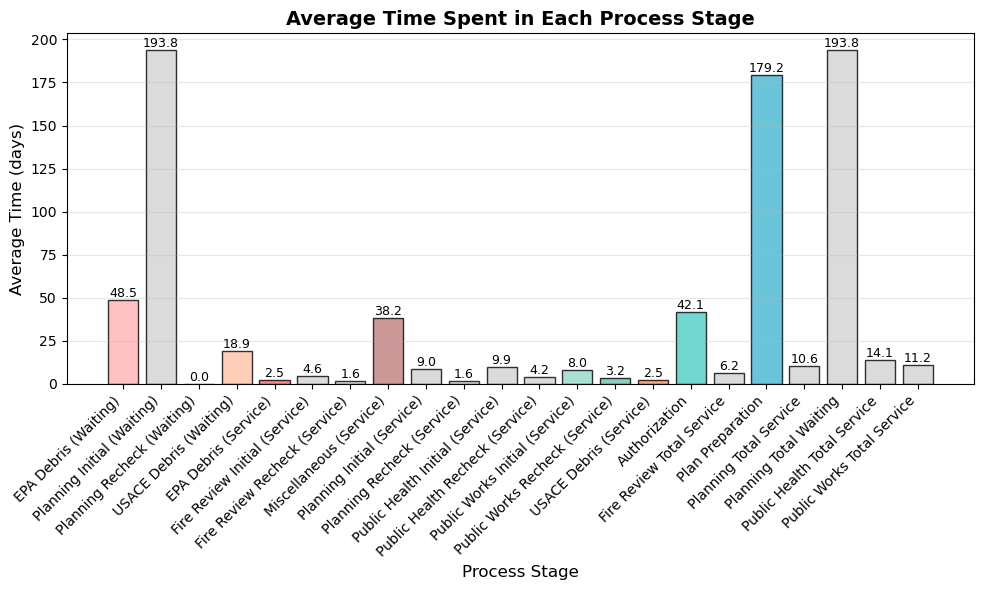

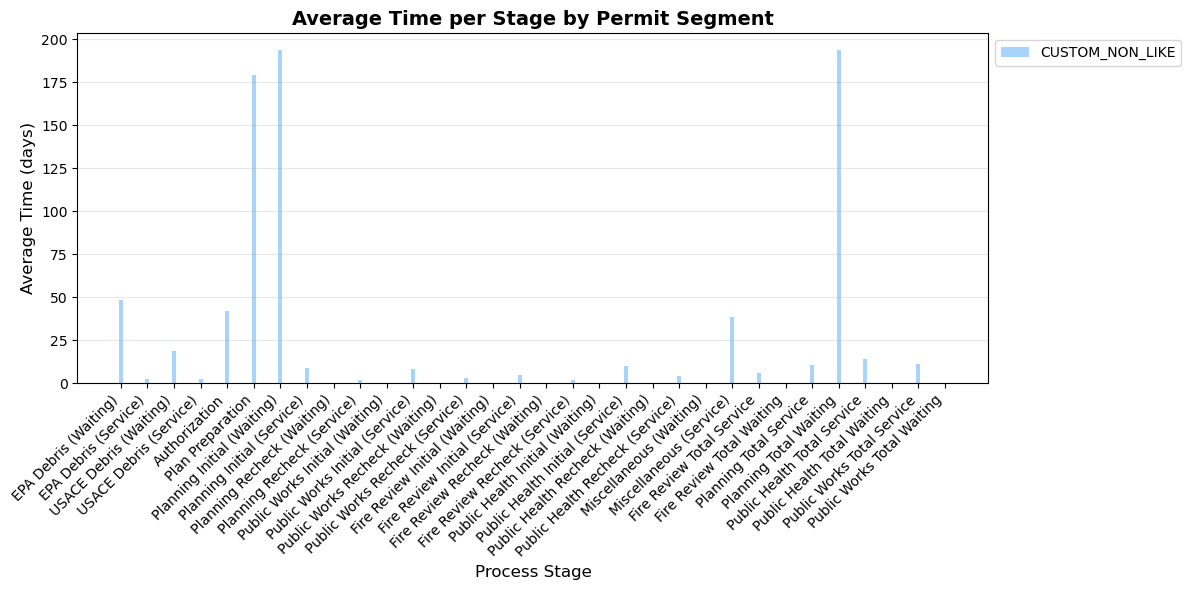

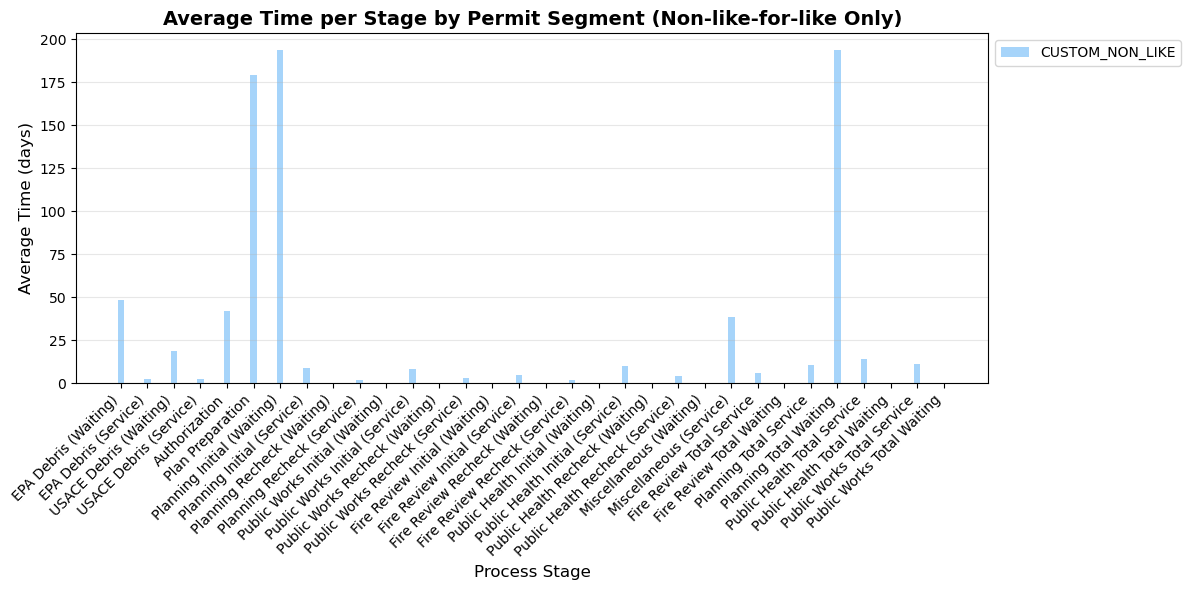

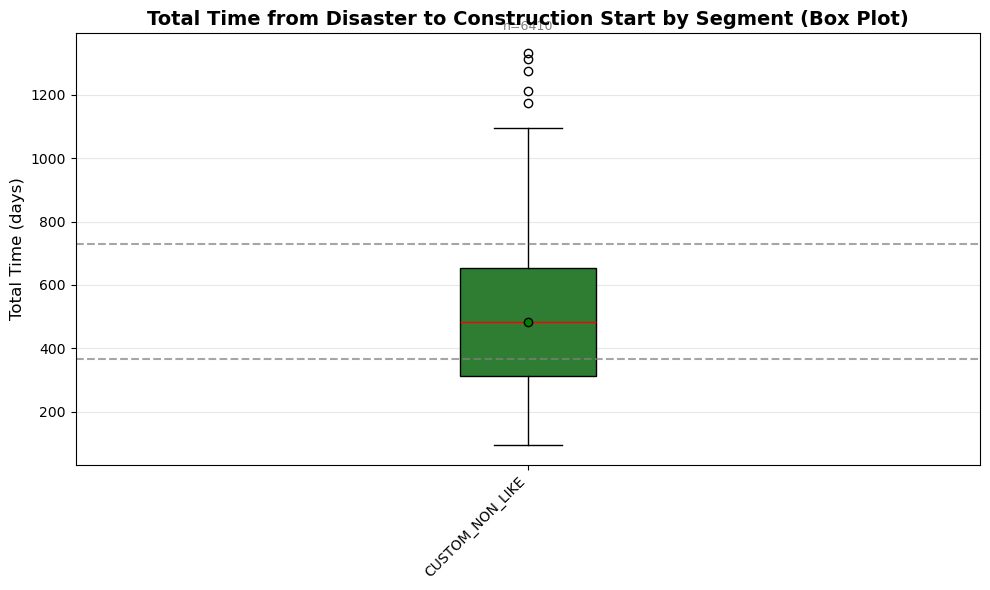

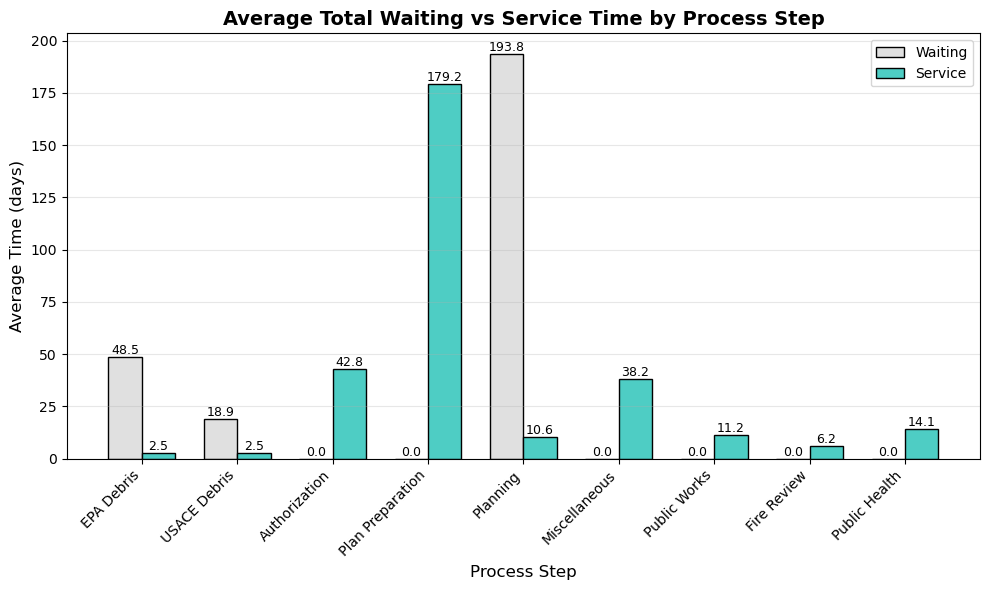

Visualizations complete!


In [4]:
# Visualize the time each permit spends in each stage
from visualize_permits import visualize_all, plot_stacked_bar_chart, plot_average_time_by_stage

# Create all visualizations
visualize_all(sim.completed_permits)

# Or create individual visualizations:
# plot_stacked_bar_chart(sim.completed_permits, max_permits=30)  # Stacked bar chart
# plot_gantt_chart(sim.completed_permits, max_permits=20)        # Gantt chart
# plot_average_time_by_stage(sim.completed_permits)              # Average time by stage
